In [2]:
import sys
sys.path.append('../src')

In [3]:
from argopy import DataFetcher

# Bay of Bengal region, small date range first — just to confirm it works
ds = DataFetcher().region([80, 100, 5, 20, 0, 1000, '2023-01-01', '2023-03-01']).to_xarray()
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:          (N_POINTS: 12655)
Coordinates:
    LATITUDE         (N_POINTS) float64 101kB 5.806 5.806 5.806 ... 9.915 9.915
    LONGITUDE        (N_POINTS) float64 101kB 85.95 85.95 85.95 ... 86.73 86.73
    TIME             (N_POINTS) datetime64[ns] 101kB 2023-01-01T03:23:36 ... ...
  * N_POINTS         (N_POINTS) int64 101kB 0 1 2 3 ... 12651 12652 12653 12654
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 101kB 108 108 108 108 ... 263 263 263 263
    DATA_MODE        (N_POINTS) <U1 51kB 'D' 'D' 'D' 'D' 'D' ... 'D' 'D' 'D' 'D'
    DIRECTION        (N_POINTS) <U1 51kB 'A' 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 101kB 2902769 2902769 ... 2902264 2902264
    POSITION_QC      (N_POINTS) int64 101kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 51kB 0.3 1.0 2.0 ... 974.8 984.7 994.9
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 51kB 0.01 0.01 0.01 ... 0.01 

In [4]:
import copernicusmarine

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["thetao"],
    minimum_longitude=80, maximum_longitude=100,
    minimum_latitude=5, maximum_latitude=20,
    start_datetime="2023-01-01", end_datetime="2023-01-31",
    minimum_depth=0, maximum_depth=1,
    output_filename="test_sst_jan2023.nc",
    output_directory="data/raw"
)

c:\Users\LENOVO\miniconda3\envs\oceanembed\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO - 2026-09-07T18:28:29Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO - 2026-09-07T18:28:50Z - Selected dataset version: "202311"
INFO - 2026-09-07T18:28:50Z - Selected dataset part: "default"
WARNING - 2026-09-07T18:28:50Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
100%|██████████| [00:13<00:00]
INFO - 2026-09-07T18:29:19Z - Total size of the download: 2.59 MB.


ResponseSubset(file_path=WindowsPath('data/raw/test_sst_jan2023_(6).nc'), output_directory=WindowsPath('data/raw'), filename='test_sst_jan2023_(6).nc', file_size=2.593631679389313, data_transfer_size=992.5452213740458, variables=['thetao'], coordinates_extent=[GeographicalExtent(minimum=80.0, maximum=100.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=5.0, maximum=20.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2023-01-01T00:00:00+00:00', maximum='2023-01-31T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=0.49402499198913574, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [5]:
import xarray as xr

ds_sst = xr.open_dataset("data/raw/test_sst_jan2023.nc")
print(ds_sst)

<xarray.Dataset> Size: 11MB
Dimensions:    (time: 31, depth: 1, latitude: 181, longitude: 241)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 724B 5.0 5.083 5.167 5.25 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 964B 80.0 80.08 80.17 ... 99.83 99.92 100.0
  * time       (time) datetime64[ns] 248B 2023-01-01 2023-01-02 ... 2023-01-31
Data variables:
    thetao     (time, depth, latitude, longitude) float64 11MB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                   

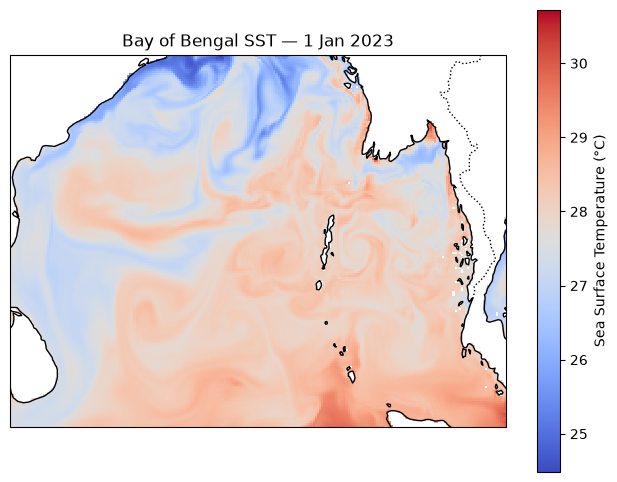

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ds_sst['thetao'].isel(time=0, depth=0).plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm',
    cbar_kwargs={'label': 'Sea Surface Temperature (°C)'}
)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Bay of Bengal SST — 1 Jan 2023')
plt.show()


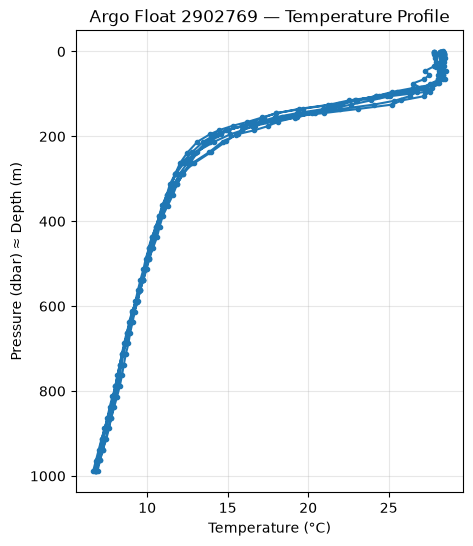

In [7]:
# Pick one float's first profile
float_id = ds['PLATFORM_NUMBER'].values[0]
profile_mask = ds['PLATFORM_NUMBER'] == float_id

plt.figure(figsize=(5, 6))
plt.plot(ds['TEMP'].where(profile_mask), ds['PRES'].where(profile_mask), 'o-', markersize=3)
plt.gca().invert_yaxis()  # depth increases downward
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (dbar) ≈ Depth (m)')
plt.title(f'Argo Float {float_id} — Temperature Profile')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
import copernicusmarine

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m",
    variables=["thetao"],
    minimum_longitude=80, maximum_longitude=100,
    minimum_latitude=5, maximum_latitude=20,
    start_datetime="2026-01-01", end_datetime="2026-01-31",
    minimum_depth=0, maximum_depth=1,
    output_filename="test_sst_jan2026.nc",
    output_directory="data/raw"
)

INFO - 2026-09-07T18:29:22Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO - 2026-09-07T18:29:38Z - Selected dataset version: "202406"
INFO - 2026-09-07T18:29:38Z - Selected dataset part: "default"
WARNING - 2026-09-07T18:29:38Z - Some of your subset selection [0.0, 1.0] for the depth dimension exceed the dataset coordinates [0.49402499198913574, 5727.9169921875]
100%|██████████| [00:08<00:00]
INFO - 2026-09-07T18:29:51Z - Total size of the download: 5.17 MB.


ResponseSubset(file_path=WindowsPath('data/raw/test_sst_jan2026_(2).nc'), output_directory=WindowsPath('data/raw'), filename='test_sst_jan2026_(2).nc', file_size=5.174263358778626, data_transfer_size=146.6430534351145, variables=['thetao'], coordinates_extent=[GeographicalExtent(minimum=80.0, maximum=100.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=5.0, maximum=20.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2026-01-01T00:00:00+00:00', maximum='2026-01-31T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.49402499198913574, maximum=0.49402499198913574, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [9]:
from argopy import DataFetcher

ds_2026 = DataFetcher().region([80, 100, 5, 20, 0, 1000, '2026-01-01', '2026-03-01']).to_xarray()
print(ds_2026)

<xarray.Dataset> Size: 4MB
Dimensions:          (N_POINTS: 32917)
Coordinates:
    LATITUDE         (N_POINTS) float64 263kB 5.46 5.46 5.46 ... 5.062 5.062
    LONGITUDE        (N_POINTS) float64 263kB 85.59 85.59 85.59 ... 90.1 90.1
    TIME             (N_POINTS) datetime64[ns] 263kB 2026-01-01T02:55:00 ... ...
  * N_POINTS         (N_POINTS) int64 263kB 0 1 2 3 ... 32913 32914 32915 32916
Data variables: (12/15)
    CYCLE_NUMBER     (N_POINTS) int64 263kB 64 64 64 64 64 64 ... 39 39 39 39 39
    DATA_MODE        (N_POINTS) <U1 132kB 'A' 'A' 'A' 'A' ... 'R' 'R' 'R' 'R'
    DIRECTION        (N_POINTS) <U1 132kB 'A' 'A' 'A' 'A' ... 'A' 'A' 'A' 'A'
    PLATFORM_NUMBER  (N_POINTS) int64 263kB 5907086 5907086 ... 1902367 1902367
    POSITION_QC      (N_POINTS) int64 263kB 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    PRES             (N_POINTS) float32 132kB 3.3 5.4 7.4 ... 996.0 998.0 1e+03
    ...               ...
    PSAL_ERROR       (N_POINTS) float32 132kB nan nan nan nan ... nan nan nan


<xarray.Dataset> Size: 5MB
Dimensions:    (time: 31, depth: 1, latitude: 181, longitude: 241)
Coordinates:
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 724B 5.0 5.083 5.167 5.25 ... 19.83 19.92 20.0
  * longitude  (longitude) float32 964B 80.0 80.08 80.17 ... 99.83 99.92 100.0
  * time       (time) datetime64[ns] 248B 2026-01-01 2026-01-02 ... 2026-01-31
Data variables:
    thetao     (time, depth, latitude, longitude) float32 5MB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:    

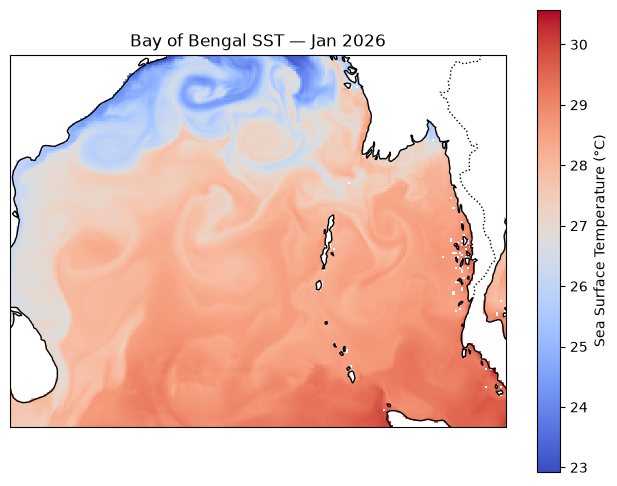

In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds_sst = xr.open_dataset("data/raw/test_sst_jan2026.nc")
print(ds_sst)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ds_sst['thetao'].isel(time=0, depth=0).plot(
    ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm',
    cbar_kwargs={'label': 'Sea Surface Temperature (°C)'}
)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('Bay of Bengal SST — Jan 2026')
plt.show()

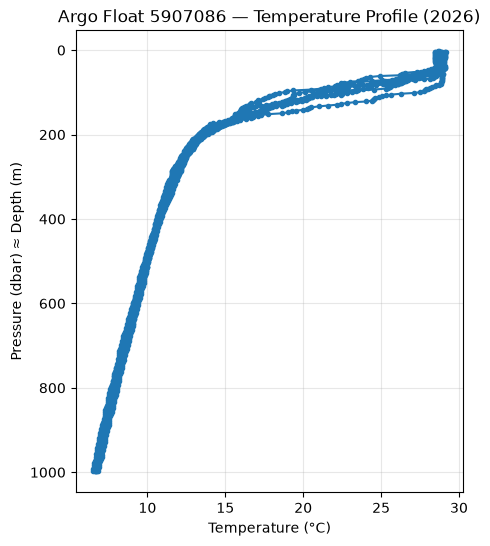

In [11]:
import matplotlib.pyplot as plt

# Pick one float's first profile
float_id = ds_2026['PLATFORM_NUMBER'].values[0]
profile_mask = ds_2026['PLATFORM_NUMBER'] == float_id

plt.figure(figsize=(5, 6))
plt.plot(ds_2026['TEMP'].where(profile_mask), ds_2026['PRES'].where(profile_mask), 'o-', markersize=3)
plt.gca().invert_yaxis()
plt.xlabel('Temperature (°C)')
plt.ylabel('Pressure (dbar) ≈ Depth (m)')
plt.title(f'Argo Float {float_id} — Temperature Profile (2026)')
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
import numpy as np

# pick this Argo profile's location and near-surface temp
lat_pt = float(ds_2026['LATITUDE'].values[0])
lon_pt = float(ds_2026['LONGITUDE'].values[0])
argo_sst = float(ds_2026['TEMP'].where(ds_2026['PRES'] < 10).mean())

# nearest grid point from your satellite/reanalysis file
model_sst = float(ds_sst['thetao'].sel(
    latitude=lat_pt, longitude=lon_pt, method="nearest"
).isel(time=0, depth=0))

print(f"Argo float location: lat={lat_pt:.2f}, lon={lon_pt:.2f}")
print(f"Argo near-surface temp: {argo_sst:.2f} °C")
print(f"Model/satellite temp at same point: {model_sst:.2f} °C")
print(f"Difference: {abs(argo_sst - model_sst):.2f} °C")

Argo float location: lat=5.46, lon=85.59
Argo near-surface temp: 27.58 °C
Model/satellite temp at same point: 29.06 °C
Difference: 1.48 °C


In [13]:
argo_date = ds_2026['TIME'].values[0]  # the float's actual profile date
model_sst = float(ds_sst['thetao'].sel(
    latitude=lat_pt, longitude=lon_pt, time=argo_date, method="nearest"
).isel(depth=0))

In [14]:
print(f"Argo profile date: {argo_date}")
print(f"Argo near-surface temp: {argo_sst:.2f} °C")
print(f"Model/satellite temp (same date + location): {model_sst:.2f} °C")
print(f"Difference: {abs(argo_sst - model_sst):.2f} °C")

Argo profile date: 2026-01-01T02:55:00.000000000
Argo near-surface temp: 27.58 °C
Model/satellite temp (same date + location): 29.06 °C
Difference: 1.48 °C


In [15]:
import pandas as pd
import numpy as np

# Flatten to one row per (float, profile), keeping near-surface temp only
df = ds_2026[['PLATFORM_NUMBER', 'CYCLE_NUMBER', 'LATITUDE', 'LONGITUDE', 'TIME', 'PRES', 'TEMP']].to_dataframe().reset_index()

profiles = (
    df[df['PRES'] < 10]
    .groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER'])
    .agg(lat=('LATITUDE', 'first'),
         lon=('LONGITUDE', 'first'),
         time=('TIME', 'first'),
         argo_temp=('TEMP', 'mean'))
    .reset_index()
)

print(f"Total independent Argo profiles found: {len(profiles)}")

Total independent Argo profiles found: 224


In [16]:
profiles_jan = profiles[(profiles['time'] >= '2026-01-01') & (profiles['time'] <= '2026-01-31')].copy()
print(f"Profiles usable for this comparison (Jan 2026 only): {len(profiles_jan)}")

Profiles usable for this comparison (Jan 2026 only): 115


In [17]:
model_temps = []
for _, row in profiles_jan.iterrows():
    try:
        val = float(ds_sst['thetao'].sel(
            latitude=row['lat'], longitude=row['lon'], time=row['time'], method='nearest'
        ).isel(depth=0))
    except Exception:
        val = np.nan
    model_temps.append(val)

profiles_jan['model_temp'] = model_temps
profiles_jan['abs_diff'] = (profiles_jan['argo_temp'] - profiles_jan['model_temp']).abs()
profiles_jan = profiles_jan.dropna(subset=['model_temp'])

print(profiles_jan[['PLATFORM_NUMBER', 'lat', 'lon', 'time', 'argo_temp', 'model_temp', 'abs_diff']])

     PLATFORM_NUMBER        lat        lon                time  argo_temp  \
3            1902373  14.387910  90.347310 2026-01-04 17:50:42  28.460445   
4            1902373  14.128990  90.171930 2026-01-15 00:43:10  26.827778   
5            1902373  13.890020  89.914500 2026-01-25 07:17:34  27.808701   
9            1902594   9.767601  86.616005 2026-01-02 17:51:34  28.344572   
10           1902594   9.926865  86.672460 2026-01-12 12:14:27  27.915144   
..               ...        ...        ...                 ...        ...   
214          7902249   8.800000  83.016667 2026-01-13 14:02:37  27.833275   
215          7902249   8.609640  82.965180 2026-01-23 14:09:49  27.871727   
219          7902251  11.083333  89.166667 2026-01-03 14:15:54  28.161999   
220          7902251  11.283333  89.316667 2026-01-13 13:59:55  27.988182   
221          7902251  11.600000  89.516667 2026-01-23 14:03:09  28.168182   

     model_temp  abs_diff  
3     28.019751  0.440695  
4     27.393164  0.

In [18]:
mean_diff = profiles_jan['abs_diff'].mean()
std_diff = profiles_jan['abs_diff'].std()

print(f"Validated across {len(profiles_jan)} independent Argo profiles (Jan 2026)")
print(f"Mean absolute difference: {mean_diff:.2f} °C")
print(f"Standard deviation: {std_diff:.2f} °C")

Validated across 115 independent Argo profiles (Jan 2026)
Mean absolute difference: 0.22 °C
Standard deviation: 0.26 °C


In [19]:
import xarray as xr

en4_jan = xr.open_dataset("data/raw/en4/EN.4.2.2.f.analysis.g10.202601.nc")
print(en4_jan)

<xarray.Dataset> Size: 105MB
Dimensions:                          (time: 1, depth: 42, lat: 173, lon: 360,
                                      bnds: 2)
Coordinates:
  * depth                            (depth) float32 168B 5.022 ... 5.35e+03
  * lat                              (lat) float32 692B -83.0 -82.0 ... 89.0
  * lon                              (lon) float32 1kB 1.0 2.0 ... 359.0 360.0
  * time                             (time) datetime64[ns] 8B 2026-01-16T12:0...
Dimensions without coordinates: bnds
Data variables:
    temperature                      (time, depth, lat, lon) float64 21MB ...
    salinity                         (time, depth, lat, lon) float64 21MB ...
    temperature_uncertainty          (time, depth, lat, lon) float64 21MB ...
    salinity_uncertainty             (time, depth, lat, lon) float64 21MB ...
    temperature_observation_weights  (time, depth, lat, lon) float32 10MB ...
    salinity_observation_weights     (time, depth, lat, lon) float32 10MB ..

In [20]:
import numpy as np
import pandas as pd

en4_files = {
    1: "data/raw/en4/EN.4.2.2.f.analysis.g10.202601.nc",
    2: "data/raw/en4/EN.4.2.2.f.analysis.g10.202602.nc",
    3: "data/raw/en4/EN.4.2.2.f.analysis.g10.202603.nc",
}

en4_diffs = []
for _, row in profiles.iterrows():  # your full Jan-Mar profiles table
    month = pd.Timestamp(row['time']).month
    if month not in en4_files:
        continue
    en4_ds = xr.open_dataset(en4_files[month])
    en4_temp_k = en4_ds['temperature'].sel(
        lat=row['lat'], lon=row['lon'], depth=5, method="nearest"
    ).isel(time=0)
    en4_temp_c = float(en4_temp_k) - 273.15
    en4_diffs.append({
        "platform": row['PLATFORM_NUMBER'], "lat": row['lat'], "lon": row['lon'],
        "argo_temp": row['argo_temp'], "en4_temp": en4_temp_c,
        "abs_diff": abs(row['argo_temp'] - en4_temp_c)
    })

en4_df = pd.DataFrame(en4_diffs)
print(f"Validated against {len(en4_df)} profiles using EN4")
print(f"Mean absolute difference (EN4): {en4_df['abs_diff'].mean():.2f} °C")
print(f"Standard deviation: {en4_df['abs_diff'].std():.2f} °C")

Validated against 224 profiles using EN4
Mean absolute difference (EN4): 0.31 °C
Standard deviation: 0.30 °C


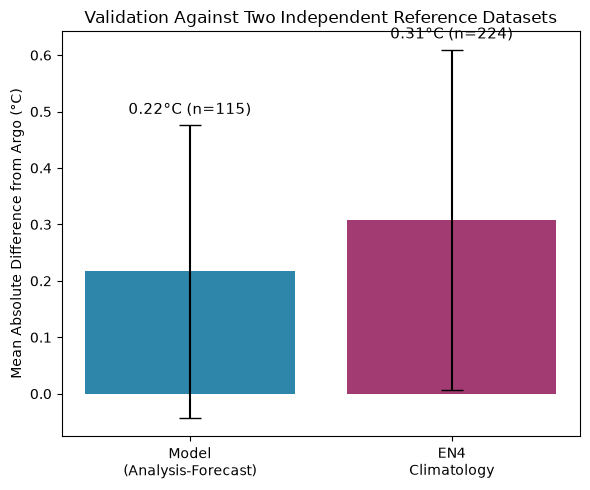

In [21]:
import matplotlib.pyplot as plt

datasets = ['Model\n(Analysis-Forecast)', 'EN4\nClimatology']
means = [profiles_jan['abs_diff'].mean(), en4_df['abs_diff'].mean()]
stds = [profiles_jan['abs_diff'].std(), en4_df['abs_diff'].std()]
counts = [len(profiles_jan), len(en4_df)]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(datasets, means, yerr=stds, capsize=8, color=['#2E86AB', '#A23B72'])
for i, (m, n) in enumerate(zip(means, counts)):
    ax.text(i, m + stds[i] + 0.02, f"{m:.2f}°C (n={n})", ha='center', fontsize=11)
ax.set_ylabel("Mean Absolute Difference from Argo (°C)")
ax.set_title("Validation Against Two Independent Reference Datasets")
plt.tight_layout()
plt.savefig("../results/validation_comparison_bar.png", dpi=200, bbox_inches="tight")
plt.show()

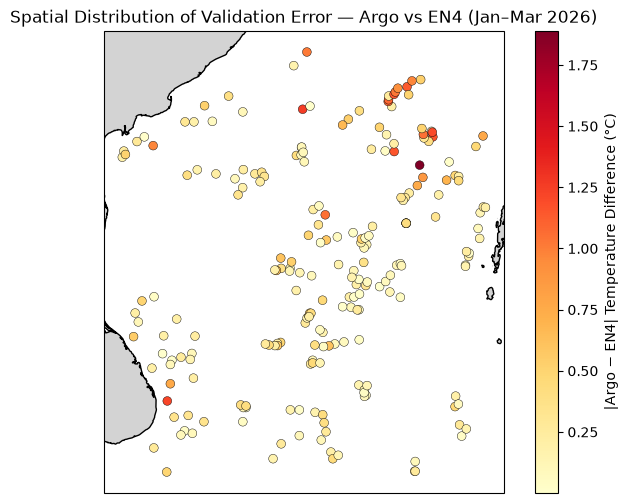

In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
sc = ax.scatter(en4_df['lon'], en4_df['lat'], c=en4_df['abs_diff'],
                 cmap='YlOrRd', s=40, edgecolor='k', linewidth=0.3,
                 transform=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.coastlines()
plt.colorbar(sc, ax=ax, label='|Argo − EN4| Temperature Difference (°C)')
ax.set_title('Spatial Distribution of Validation Error — Argo vs EN4 (Jan–Mar 2026)')
plt.savefig("../results/validation_error_map.png", dpi=200, bbox_inches="tight")
plt.show()

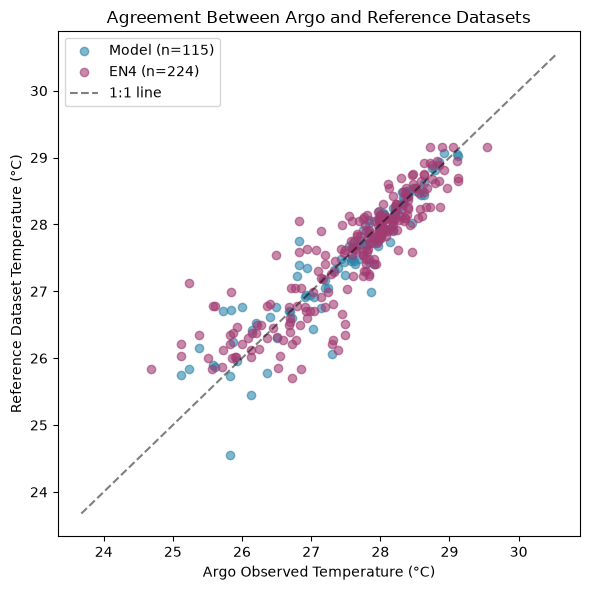

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(profiles_jan['argo_temp'], profiles_jan['model_temp'], alpha=0.6,
           label=f"Model (n={len(profiles_jan)})", color='#2E86AB')
ax.scatter(en4_df['argo_temp'], en4_df['en4_temp'], alpha=0.6,
           label=f"EN4 (n={len(en4_df)})", color='#A23B72')

lo = min(profiles_jan['argo_temp'].min(), en4_df['argo_temp'].min()) - 1
hi = max(profiles_jan['argo_temp'].max(), en4_df['argo_temp'].max()) + 1
ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='1:1 line')

ax.set_xlabel("Argo Observed Temperature (°C)")
ax.set_ylabel("Reference Dataset Temperature (°C)")
ax.set_title("Agreement Between Argo and Reference Datasets")
ax.legend()
plt.tight_layout()
plt.savefig("../results/validation_scatter_agreement.png", dpi=200, bbox_inches="tight")
plt.show()

In [24]:
import pandas as pd
import numpy as np

df_full = ds_2026[['PLATFORM_NUMBER','CYCLE_NUMBER','LATITUDE','LONGITUDE','TIME','PRES','TEMP']].to_dataframe().reset_index()
df_full = df_full.dropna(subset=['TEMP', 'PRES'])

rows = []
for (plat, cyc), grp in df_full.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']):
    lat, lon, time = grp['LATITUDE'].iloc[0], grp['LONGITUDE'].iloc[0], grp['TIME'].iloc[0]
    try:
        sst_val = float(ds_sst['thetao'].sel(latitude=lat, longitude=lon, time=time, method='nearest').isel(depth=0))
    except Exception:
        continue
    doy = pd.Timestamp(time).dayofyear
    for _, r in grp.iterrows():
        rows.append({'lat': lat, 'lon': lon, 'day_of_year': doy, 'sst': sst_val, 'depth': r['PRES'], 'temp': r['TEMP']})

train_df = pd.DataFrame(rows)
train_df.to_csv('data/processed/training_table.csv', index=False)
print(train_df.shape)

(32917, 6)


In [25]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

X = train_df[['lat', 'lon', 'day_of_year', 'sst', 'depth']]
y = train_df['temp']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, preds))

MAE: 0.14813040339932262


In [26]:
import joblib
joblib.dump(model, '../results/baseline_xgb_model.pkl')

def predict_profile(lat, lon, date, depths=[0,10,25,50,75,100,150,200,300,500,700,1000]):
    doy = pd.Timestamp(date).dayofyear
    sst_val = float(ds_sst['thetao'].sel(latitude=lat, longitude=lon, time=str(date), method='nearest').isel(depth=0))
    rows = pd.DataFrame({
        'lat': [lat]*len(depths), 'lon': [lon]*len(depths),
        'day_of_year': [doy]*len(depths), 'sst': [sst_val]*len(depths), 'depth': depths
    })
    preds = model.predict(rows)
    return list(zip(depths, preds))

In [27]:
model_mae = mean_absolute_error(y_test, preds)
print(f"Baseline model MAE: {model_mae:.2f} °C (vs. 0.22 °C raw satellite agreement)")

Baseline model MAE: 0.15 °C (vs. 0.22 °C raw satellite agreement)


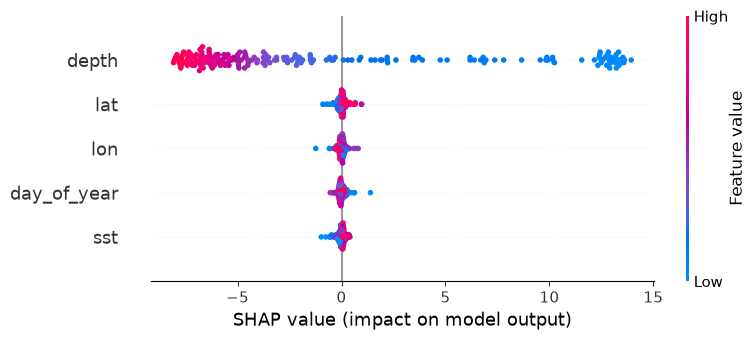

In [28]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.sample(200, random_state=1))
shap.summary_plot(shap_values, X_test.sample(200, random_state=1), show=False)
import matplotlib.pyplot as plt
plt.savefig('../results/shap_summary.png', dpi=200, bbox_inches='tight')

In [29]:
from sklearn.model_selection import GroupShuffleSplit

groups = train_df.groupby(['lat', 'lon', 'day_of_year']).ngroup()  # unique ID per profile
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(train_df, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model2 = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05)
model2.fit(X_train, y_train)
preds2 = model2.predict(X_test)
print("Honest MAE (profile-level split):", mean_absolute_error(y_test, preds2))

Honest MAE (profile-level split): 0.41647965058839803


In [32]:
copernicusmarine.describe(contains=["ssh"])
copernicusmarine.describe(contains=["sss"])

Fetching catalogue 1: 100%|██████████| 2/2 [01:00<00:00, 30.16s/it]


CopernicusMarineCatalogue(products=[CopernicusMarineProduct(title='SMOS CATDS Qualified (L2Q) Sea Surface Salinity product', product_id='MULTIOBS_GLO_PHY_SSS_L3_MYNRT_015_014', thumbnail_url='https://mdl-metadata.s3.waw3-1.cloudferro.com/metadata/thumbnails/MULTIOBS_GLO_PHY_SSS_L3_MYNRT_015_014.jpg', description="The product MULTIOBS_GLO_PHY_SSS_L3_MYNRT_015_014 is a reformatting and a simplified version of the CATDS L3 product called “2Q” or “L2Q”. it is an intermediate product, that provides, in daily files, SSS corrected from land-sea contamination and latitudinal bias, with/without rain freshening correction.\n\n**References:**\n\n* Boutin, J., J. L. Vergely, S. Marchand, F. D'Amico, A. Hasson, N. Kolodziejczyk, N. Reul, G. Reverdin, and J. Vialard (2018), New SMOS Sea Surface Salinity with reduced systematic errors and improved variability, Remote Sensing of Environment, 214, 115-134. doi:https://doi.org/10.1016/j.rse.2018.05.022\n* Kolodziejczyk, N., J. Boutin, J.-L. Vergely, S. 

In [37]:
LON_MIN, LON_MAX = 80, 100
LAT_MIN, LAT_MAX = 5, 20

In [38]:
sss = copernicusmarine.open_dataset(
    dataset_id="cmems_obs-mob_glo_phy-sss_nrt_multi_P1D",
    variables=["sos"],  # sea surface salinity
    minimum_longitude=LON_MIN, maximum_longitude=LON_MAX,
    minimum_latitude=LAT_MIN, maximum_latitude=LAT_MAX,
    start_datetime="2026-01-01", end_datetime="2026-01-31",
)

INFO - 2026-09-07T18:37:24Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


INFO - 2026-09-07T18:37:41Z - Selected dataset version: "202607"
INFO - 2026-09-07T18:37:41Z - Selected dataset part: "default"


In [39]:
print(sss)
print(sss['sos'].isel(time=0).mean().values)  # should NOT be all NaN

<xarray.Dataset> Size: 5MB
Dimensions:    (time: 31, depth: 1, latitude: 120, longitude: 160)
Coordinates:
  * depth      (depth) float32 4B 0.0
  * latitude   (latitude) float32 480B 5.062 5.188 5.312 ... 19.69 19.81 19.94
  * longitude  (longitude) float32 640B 80.06 80.19 80.31 ... 99.69 99.81 99.94
  * time       (time) datetime64[ns] 248B 2026-01-01 2026-01-02 ... 2026-01-31
Data variables:
    sos        (time, depth, latitude, longitude) float64 5MB dask.array<chunksize=(31, 1, 120, 160), meta=np.ndarray>
Attributes: (12/17)
    Conventions:               CF-1.7
    Scaling_Equation:          (scale_factor*data) + add_offset
    contact:                   servicedesk.cmems@mercator-ocean.eu
    creation_date:             Mon 29 Jun 2026 08:39:26
    easternmost_longitude:     179.9375
    grid_resolution:           0.125 degrees
    ...                        ...
    references:                Buongiorno Nardelli, B., R. Droghei, and R. Sa...
    software_version:          SSS/S

In [41]:
sss_val = float(sss['sos'].sel(latitude=lat, longitude=lon, time=time, method='nearest').isel(depth=0))

In [42]:
print(sss_val)  # should print a single number, roughly 30-35 for this region

33.402740478515625


In [43]:
rows = []
for (plat, cyc), grp in df_full.groupby(['PLATFORM_NUMBER', 'CYCLE_NUMBER']):
    lat, lon, time = grp['LATITUDE'].iloc[0], grp['LONGITUDE'].iloc[0], grp['TIME'].iloc[0]
    try:
        sst_val = float(ds_sst['thetao'].sel(latitude=lat, longitude=lon, time=time, method='nearest').isel(depth=0))
        sss_val = float(sss['sos'].sel(latitude=lat, longitude=lon, time=time, method='nearest').isel(depth=0))
    except Exception:
        continue
    doy = pd.Timestamp(time).dayofyear
    for _, r in grp.iterrows():
        rows.append({'lat': lat, 'lon': lon, 'day_of_year': doy, 'sst': sst_val, 'sss': sss_val, 'depth': r['PRES'], 'temp': r['TEMP']})

train_df = pd.DataFrame(rows)
print(train_df.shape)

(32917, 7)


In [44]:
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

X = train_df[['lat', 'lon', 'day_of_year', 'sst', 'sss', 'depth']]
y = train_df['temp']

groups = train_df.groupby(['lat', 'lon', 'day_of_year']).ngroup()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(train_df, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print("Honest MAE (SST+SSS, profile-level split):", mean_absolute_error(y_test, preds))

Honest MAE (SST+SSS, profile-level split): 0.40261822507207334


In [46]:
import joblib
joblib.dump(model, '../results/baseline_xgb_model.pkl')

def predict_profile(lat, lon, date, sst_val, sss_val, depths=[0,10,25,50,75,100,150,200,300,500,700,1000]):
    doy = pd.Timestamp(date).dayofyear
    rows = pd.DataFrame({
        'lat': [lat]*len(depths), 'lon': [lon]*len(depths),
        'day_of_year': [doy]*len(depths), 'sst': [sst_val]*len(depths),
        'sss': [sss_val]*len(depths), 'depth': depths
    })
    preds = model.predict(rows)
    return list(zip(depths, preds))

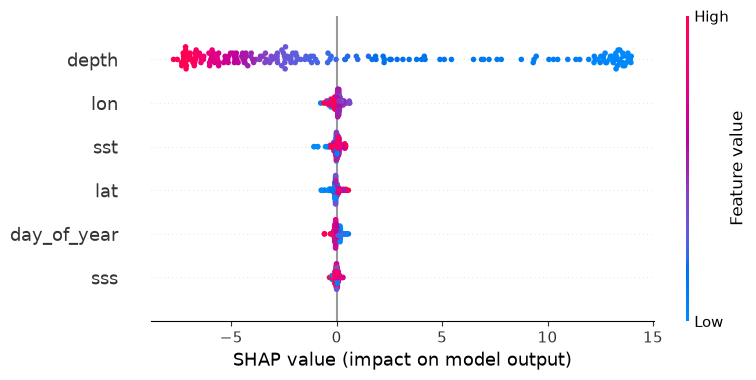

In [48]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.sample(200, random_state=1))
shap.summary_plot(shap_values, X_test.sample(200, random_state=1), show=False)
import matplotlib.pyplot as plt
plt.savefig('../results/shap_summary_v2.png', dpi=200, bbox_inches='tight')